# Hospital Patient Data Analysis

**Context:** A hospital maintains patient records including admission details, department, diagnosis, doctor, and bill amount. We have two datasets — one with patient info (`Patient_Data.csv`) and another with billing details (`Billing_Data.csv`). Some patients have blank bill amounts, and there are multiple rows for the same patient due to follow-ups.

**Tasks covered in this notebook:**
1. Load the patient dataset and show summary with `.info()`
2. Select columns relevant for billing
3. Drop administrative columns
4. Groupby: total bill amount per department
5. Remove duplicate patient records
6. Fill missing `BillAmount` values with the mean
7. Merge the billing data with the patient data on `PatientID`
8. Concatenate new patients for the current week (row-wise)
9. Concatenate new billing category columns (column-wise)

## Setup

Import the libraries needed and load the patient dataset.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100

## Task 1. Load the Patient Dataset and Show Summary with `.info()`

In [2]:
# Load the patient dataset
patient_df = pd.read_csv("Patient_Data.csv")

print(f"Shape: {patient_df.shape[0]} rows x {patient_df.shape[1]} columns")
patient_df

Shape: 6 rows x 7 columns


   PatientID     Name  ... ReceptionistID       CheckInTime
0        101    Alice  ...              1  2023-01-10 09:00
1        102      Bob  ...              2  2023-01-11 10:30
2        103  Charlie  ...              1  2023-01-12 11:00
3        104    David  ...              3  2023-01-13 12:00
4        105      Eva  ...              2  2023-01-14 08:45
5        101    Alice  ...              1  2023-01-10 09:00

[6 rows x 7 columns]

In [3]:
# .info() shows column dtypes, non-null counts, and memory usage
patient_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PatientID       6 non-null      int64  
 1   Name            6 non-null      str    
 2   Department      6 non-null      str    
 3   Doctor          6 non-null      str    
 4   BillAmount      4 non-null      float64
 5   ReceptionistID  6 non-null      int64  
 6   CheckInTime     6 non-null      str    
dtypes: float64(1), int64(2), str(4)
memory usage: 468.0 bytes


**Observations from `.info()`:**
- There are 6 rows but only 5 unique patients — row 5 is an exact duplicate of row 0 (Alice / PatientID 101), consistent with the context that some patients have multiple rows due to follow-ups.
- `BillAmount` has only 4 non-null values out of 6 — two rows (Bob and Eva) have a missing bill amount.

## Task 2. Select Columns Relevant for Billing

Extract just the columns needed for billing analysis: `PatientID`, `Department`, `Doctor`, `BillAmount`.

In [4]:
# Select only the billing-relevant columns into their own DataFrame
billing_df = patient_df[["PatientID", "Department", "Doctor", "BillAmount"]].copy()
billing_df

   PatientID   Department     Doctor  BillAmount
0        101   Cardiology  Dr. Smith      5000.0
1        102    Neurology   Dr. John         NaN
2        103  Orthopedics    Dr. Lee      7500.0
3        104   Cardiology  Dr. Smith      6200.0
4        105  Dermatology   Dr. Rose         NaN
5        101   Cardiology  Dr. Smith      5000.0

## Task 3. Drop Administrative Columns

Drop `ReceptionistID` and `CheckInTime` from the main patient dataset — these are internal front-desk fields not needed for billing or clinical analysis.

In [5]:
# Drop administrative columns from the main patient dataset
patient_clean_df = patient_df.drop(columns=["ReceptionistID", "CheckInTime"])
patient_clean_df

   PatientID     Name   Department     Doctor  BillAmount
0        101    Alice   Cardiology  Dr. Smith      5000.0
1        102      Bob    Neurology   Dr. John         NaN
2        103  Charlie  Orthopedics    Dr. Lee      7500.0
3        104    David   Cardiology  Dr. Smith      6200.0
4        105      Eva  Dermatology   Dr. Rose         NaN
5        101    Alice   Cardiology  Dr. Smith      5000.0

## Task 4. Total Bill Amount per Department (groupby)

Group the billing data by `Department` and sum `BillAmount`, using the data exactly as loaded (i.e., **before** removing the duplicate row or filling missing values).

**Note:** `.sum()` skips `NaN` values by default, so the two missing bill amounts (Bob, Eva) don't cause an error — but the duplicate Alice row *is* still counted twice at this point, since duplicates haven't been removed yet. We'll recompute this after cleaning to see the corrected totals.

In [6]:
# Total bill amount per department, using the data as-is (duplicates + missing values still present)
dept_totals_before_cleaning = billing_df.groupby("Department")["BillAmount"].sum()
print("Total bill amount per department (BEFORE removing duplicates / filling missing values):")
dept_totals_before_cleaning

Total bill amount per department (BEFORE removing duplicates / filling missing values):


Department
Cardiology     16200.0
Dermatology        0.0
Neurology          0.0
Orthopedics     7500.0
Name: BillAmount, dtype: float64

**Reading this result carefully:** Neurology and Dermatology show as **0.0**, not because those patients had no bill, but because `.sum()` treats an all-missing group as 0 by default — Bob and Eva are each the *only* row in their department, and their `BillAmount` is missing. This is exactly the kind of misleading "before cleaning" result the assignment wants us to catch and fix.

## Task 5. Remove Duplicate Patient Records

Remove duplicate rows based on `PatientID`, keeping the first occurrence. This is applied to both the billing subset and the cleaned patient dataset, since the duplicate (Alice, PatientID 101) appears in the original source data used for both.

In [7]:
print(f"Rows in billing_df before dedup: {len(billing_df)}")
print(f"Rows in patient_clean_df before dedup: {len(patient_clean_df)}")

# Drop duplicate patient records, keeping the first occurrence of each PatientID
billing_df = billing_df.drop_duplicates(subset="PatientID", keep="first").reset_index(drop=True)
patient_clean_df = patient_clean_df.drop_duplicates(subset="PatientID", keep="first").reset_index(drop=True)

print(f"Rows in billing_df after dedup: {len(billing_df)}")
print(f"Rows in patient_clean_df after dedup: {len(patient_clean_df)}")

billing_df

Rows in billing_df before dedup: 6
Rows in patient_clean_df before dedup: 6
Rows in billing_df after dedup: 5
Rows in patient_clean_df after dedup: 5


   PatientID   Department     Doctor  BillAmount
0        101   Cardiology  Dr. Smith      5000.0
1        102    Neurology   Dr. John         NaN
2        103  Orthopedics    Dr. Lee      7500.0
3        104   Cardiology  Dr. Smith      6200.0
4        105  Dermatology   Dr. Rose         NaN

## Task 6. Fill Missing `BillAmount` Values with the Mean

Fill the missing `BillAmount` values (Bob, Eva) with the mean bill amount, computed from the remaining valid (non-null, de-duplicated) values.

In [8]:
# Compute the mean of the known bill amounts and use it to fill the missing values
mean_bill = billing_df["BillAmount"].mean()
print(f"Mean bill amount (from non-missing values): {mean_bill:.2f}")

billing_df["BillAmount"] = billing_df["BillAmount"].fillna(mean_bill)
print("\nBilling data after filling missing values:")
billing_df

Mean bill amount (from non-missing values): 6233.33

Billing data after filling missing values:


   PatientID   Department     Doctor   BillAmount
0        101   Cardiology  Dr. Smith  5000.000000
1        102    Neurology   Dr. John  6233.333333
2        103  Orthopedics    Dr. Lee  7500.000000
3        104   Cardiology  Dr. Smith  6200.000000
4        105  Dermatology   Dr. Rose  6233.333333

**Recomputing department totals after cleaning**, to show the corrected figures now that the duplicate row is gone and the missing values are filled:

In [9]:
dept_totals_after_cleaning = billing_df.groupby("Department")["BillAmount"].sum()
print("Total bill amount per department (AFTER removing duplicates / filling missing values):")
dept_totals_after_cleaning

Total bill amount per department (AFTER removing duplicates / filling missing values):


Department
Cardiology     11200.000000
Dermatology     6233.333333
Neurology       6233.333333
Orthopedics     7500.000000
Name: BillAmount, dtype: float64

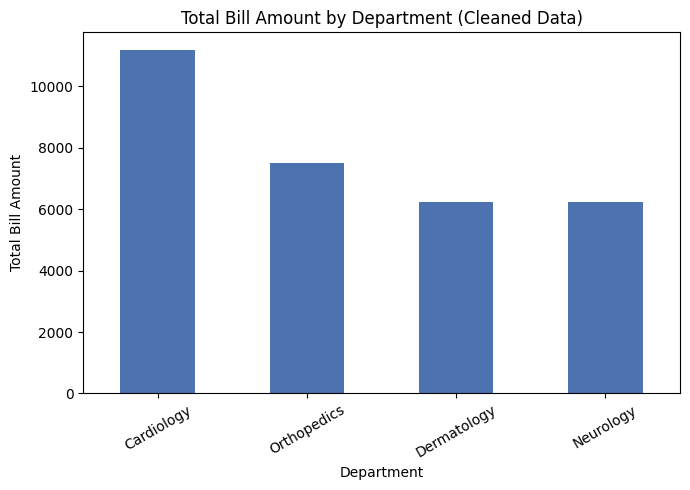

In [10]:
# Visualize department-wise revenue after cleaning
fig, ax = plt.subplots(figsize=(7, 5))
dept_totals_after_cleaning.sort_values(ascending=False).plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Total Bill Amount by Department (Cleaned Data)")
ax.set_xlabel("Department")
ax.set_ylabel("Total Bill Amount")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Task 7. Merge the Billing Data with the Patient Data on `PatientID`

`patient_clean_df` and `billing_df` both currently carry `Department`, `Doctor`, and `BillAmount` (they were derived from the same source columns), so merging them directly would create duplicate/overlapping columns. To merge meaningfully, we keep only the patient's **identity** field (`PatientID`, `Name`) from `patient_clean_df` and bring in the **billing** fields (`Department`, `Doctor`, `BillAmount`, now cleaned) from `billing_df` — this reflects a realistic setup where patient identity data and billing data are maintained separately and joined by `PatientID`.

In [11]:
# Keep only identity columns from the patient dataset
patient_identity_df = patient_clean_df[["PatientID", "Name"]]

# Merge patient identity with the cleaned billing data on PatientID
merged_df = pd.merge(patient_identity_df, billing_df, on="PatientID", how="inner")
merged_df

   PatientID     Name   Department     Doctor   BillAmount
0        101    Alice   Cardiology  Dr. Smith  5000.000000
1        102      Bob    Neurology   Dr. John  6233.333333
2        103  Charlie  Orthopedics    Dr. Lee  7500.000000
3        104    David   Cardiology  Dr. Smith  6200.000000
4        105      Eva  Dermatology   Dr. Rose  6233.333333

## Task 8. Concatenate New Patients for the Current Week (Row-wise)

A small DataFrame representing two new patients admitted this week, with the same schema as `merged_df`. Append them as new rows.

In [12]:
# New patients admitted this week
new_patients_df = pd.DataFrame({
    "PatientID": [106, 107],
    "Name": ["Frank", "Grace"],
    "Department": ["Orthopedics", "Neurology"],
    "Doctor": ["Dr. Lee", "Dr. John"],
    "BillAmount": [6800.0, 4300.0],
})

# Concatenate row-wise (stack the new patients below the existing records)
full_patient_df = pd.concat([merged_df, new_patients_df], ignore_index=True)
full_patient_df

   PatientID     Name   Department     Doctor   BillAmount
0        101    Alice   Cardiology  Dr. Smith  5000.000000
1        102      Bob    Neurology   Dr. John  6233.333333
2        103  Charlie  Orthopedics    Dr. Lee  7500.000000
3        104    David   Cardiology  Dr. Smith  6200.000000
4        105      Eva  Dermatology   Dr. Rose  6233.333333
5        106    Frank  Orthopedics    Dr. Lee  6800.000000
6        107    Grace    Neurology   Dr. John  4300.000000

## Task 9. Concatenate New Billing Category Columns (Column-wise)

`Billing_Data.csv` provides two additional billing category columns — `InsuranceCovered` and `FinalAmount` — for the original 5 patients (101–105). To concatenate these column-wise **without misaligning rows**, both DataFrames are indexed by `PatientID` first; `pd.concat(axis=1)` then aligns rows by matching index labels rather than raw row position.

Since the two brand-new patients (106, 107) added in Task 8 aren't in `Billing_Data.csv` yet, their `InsuranceCovered`/`FinalAmount` will naturally come out as missing (`NaN`) — a realistic reflection of the fact that their insurance details haven't been processed yet.

In [13]:
# Load the additional billing category columns
extra_billing_df = pd.read_csv("Billing_Data.csv")
print("New billing category columns:")
extra_billing_df

New billing category columns:


   PatientID  InsuranceCovered  FinalAmount
0        101              2000         3000
1        102              1500         3500
2        103              2500         5000
3        104              3000         3200
4        105              1000         4000

In [14]:
# Index both DataFrames by PatientID so concat(axis=1) aligns rows correctly by patient,
# rather than by raw row position
final_df = pd.concat(
    [full_patient_df.set_index("PatientID"), extra_billing_df.set_index("PatientID")],
    axis=1
).reset_index()

final_df

   PatientID     Name   Department  ...   BillAmount  InsuranceCovered  FinalAmount
0        101    Alice   Cardiology  ...  5000.000000            2000.0       3000.0
1        102      Bob    Neurology  ...  6233.333333            1500.0       3500.0
2        103  Charlie  Orthopedics  ...  7500.000000            2500.0       5000.0
3        104    David   Cardiology  ...  6200.000000            3000.0       3200.0
4        105      Eva  Dermatology  ...  6233.333333            1000.0       4000.0
5        106    Frank  Orthopedics  ...  6800.000000               NaN          NaN
6        107    Grace    Neurology  ...  4300.000000               NaN          NaN

[7 rows x 7 columns]

**Note:** Frank (106) and Grace (107) show `NaN` for `InsuranceCovered` and `FinalAmount` — this is expected and correct, since `Billing_Data.csv` only had insurance/final-amount records for the original 5 patients. Once their insurance is processed, those rows can be updated the same way this dataset was built.

## Conclusion

**Final cleaned dataset (`final_df`)** now has:
- No duplicate patient records (the repeated Alice/101 follow-up row was removed).
- No missing `BillAmount` values (filled with the mean of known amounts).
- Patient identity, department/doctor/bill info, and insurance/final-amount details all merged into a single table, keyed on `PatientID`.
- Two new patients (Frank, Grace) added for the current week, correctly showing missing insurance data since that step hasn't happened for them yet.

**Key insight:** comparing the department totals before vs. after cleaning showed two problems in the raw data — Neurology and Dermatology appeared to have **zero** revenue (really just missing bill amounts for their one patient each), and Cardiology's total was inflated by the duplicate Alice/101 follow-up row. Both issues are corrected once duplicates are removed and missing values are filled — a good illustration of why data cleaning should happen before any aggregation used for real reporting.

This cleaned, merged dataset is now in a good shape for further analytics such as department-wise revenue tracking or doctor-level performance/billing analysis.